In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, root_mean_squared_error
# Carregar CSV como DataFrame (sem índice)
caminho_csv = 'data\dataframe_20250419.csv'  # Substitua pelo caminho correto
df = pd.read_csv(caminho_csv)
df.head()

,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,CP9,CP10,CP11,CP12,airfoil,Cl,Cd,Alpha,Re
0,0.0,0.047741,0.068567,0.032866,0.022769,0.00105,0.0,-0.048052,-0.067747,-0.03376,-0.022406,-0.00105,naca1410,-1.121109,0.015669,-9.804158,3000000
1,0.0,0.047741,0.068567,0.032866,0.022769,0.00105,0.0,-0.048052,-0.067747,-0.03376,-0.022406,-0.00105,naca1410,-1.092091,0.015091,-9.804158,3000000
2,0.0,0.047741,0.068567,0.032866,0.022769,0.00105,0.0,-0.048052,-0.067747,-0.03376,-0.022406,-0.00105,naca1410,-1.080654,0.014569,-9.804158,3000000
3,0.0,0.047741,0.068567,0.032866,0.022769,0.00105,0.0,-0.048052,-0.067747,-0.03376,-0.022406,-0.00105,naca1410,-1.057541,0.013933,-9.804158,3000000
4,0.0,0.047741,0.068567,0.032866,0.022769,0.00105,0.0,-0.048052,-0.067747,-0.03376,-0.022406,-0.00105,naca1410,-1.028489,0.013412,-9.804158,3000000


In [2]:
df.columns

Index(['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10',
       'CP11', 'CP12', 'airfoil', 'Cl', 'Cd', 'Alpha', 'Re'],
      dtype='object')

In [3]:
# Filtrar os dados para Alpha entre 0 e 15
df = df[(df['Alpha'] >= 0) & (df['Alpha'] <= 15)]

In [4]:
# Separação dos aerofólios para treino e teste
aerofolios_unicos = df['airfoil'].unique()
np.random.seed(42)
aerofolios_treino = np.random.choice(aerofolios_unicos, size=int(len(aerofolios_unicos) * 0.9), replace=False)
aerofolios_teste = [a for a in aerofolios_unicos if a not in aerofolios_treino]

print(f'Aerofólios Treino: {aerofolios_treino}')
print(f'Aerofólios Teste: {aerofolios_teste}')

Aerofólios Treino: ['naca4415' 'naca23021' 'naca23024' 'naca63A010' 'naca001035' 'naca633218'
 'naca001264' 'naca0006' 'naca001264a08' 'naca632615' 'naca631412'
 'naca632015' 'naca2424' 'naca63006' 'naca63209' 'naca631212' 'naca634421'
 'naca634221' 'naca634021' 'naca23018' 'naca1408' 'naca0012' 'naca4424'
 'naca63206' 'naca63009' 'naca1410' 'naca63A210' 'naca4418' 'naca632415'
 'naca2412' 'naca2421' 'naca001034a08' 'naca23012' 'naca2410' 'naca1412'
 'naca4421' 'naca633018' 'naca2408' 'naca2415' 'naca633418' 'naca4412'
 'naca23015' 'naca63210' 'naca633618' 'naca0009']
Aerofólios Teste: ['naca631012', 'naca001034', 'naca2418', 'naca632215', 'naca64006']


In [5]:
aerofolios_treino = ['naca632615', 'naca0012', 'naca23018', 'naca001264', 'naca632015',
 'naca631412', 'naca2424', 'naca4418', 'naca23021', 'naca631212', 'naca0006',
 'naca1408', 'naca4415', 'naca63009', 'naca63206', 'naca63006', 'naca001035',
 'naca4424', 'naca1410', 'naca632415', 'naca2412', 'naca001034a08', 'naca2410',
 'naca2421', 'naca1412', 'naca4421', 'naca23024', 'naca23012', 'naca63209',
 'naca2408', 'naca2415', 'naca001264a08', 'naca4412', 'naca23015', 'naca63210',
 'naca0009', 'naca631012', 'naca001034', 'naca63A210','naca633018','naca63A010','naca633218',
 'naca634021','naca64006','naca634421','naca634221','naca633618','naca633418']
aerofolios_teste = ['naca2418', 'naca632215','naca634021','naca64006','naca634421']

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Criar DataFrames de treino e teste
df_train_cl = df[df['airfoil'].isin(aerofolios_treino)]
df_train_cd = df_train_cl.dropna(subset=['Cd'])  # Apenas remove NaN para Cd
df_test_cl = df[df['airfoil'].isin(aerofolios_teste)]
df_test_cd = df_test_cl.dropna(subset=['Cd'])  # Apenas remove NaN para Cd

# Definir entradas (features) e saídas (targets)
features = ['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10', 'CP11', 'CP12', 'Alpha', 'Re']

X_train_cl, y_train_cl = df_train_cl[features], df_train_cl['Cl'].to_numpy().ravel()
X_test_cl, y_test_cl = df_test_cl[features], df_test_cl['Cl'].to_numpy().ravel()

X_train_cd, y_train_cd = df_train_cd[features], df_train_cd['Cd'].to_numpy().ravel()
X_test_cd, y_test_cd = df_test_cd[features], df_test_cd['Cd'].to_numpy().ravel()

# Modelos a serem testados
modelos = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'MLP': MLPRegressor(random_state=42)
}

# Dicionário para armazenar os modelos treinados e resultados
modelos_treinados = {}
resultados = {}

def calcular_acuracia(y_true, y_pred, tolerancia=0.1):
    return np.mean(np.abs(y_true - y_pred) / np.abs(y_true) <= tolerancia)

# Função de avaliação
def avaliar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    acc = calcular_acuracia(y_true, y_pred)
    return {'MAE': mae, 'R²': r2, 'MSE': mse, 'RMSE': rmse, 'Acurácia': acc}

for nome, modelo in modelos.items():
    print(f'\nTreinando {nome}...')
    
    # Treinar para Cl (mantendo todas as linhas)
    modelo_cl = modelo.fit(X_train_cl, y_train_cl)
    y_pred_cl = modelo_cl.predict(X_test_cl)
    
    # Treinar para Cd (apenas linhas sem NaN)
    modelo_cd = modelo.fit(X_train_cd, y_train_cd)
    y_pred_cd = modelo_cd.predict(X_test_cd)
    
    # Avaliar
    resultado_cl = avaliar(y_test_cl, y_pred_cl)
    resultado_cd = avaliar(y_test_cd, y_pred_cd)
    
    # Salvar modelos treinados e resultados
    modelos_treinados[nome] = {'Cl': modelo_cl, 'Cd': modelo_cd}
    resultados[nome] = {'Cl': resultado_cl, 'Cd': resultado_cd}

# Exibir resultados finais formatados
print("\n📊 Resultados de todos os modelos:\n")
print(f"{'Modelo':<20}{'MAE Cl':<10}{'MSE Cl':<10}{'RMSE Cl':<10}{'R² Cl':<10}{'Acc Cl':<10}{'MAE Cd':<10}{'MSE Cd':<10}{'RMSE Cd':<10}{'R² Cd':<10}{'Acc Cd':<10}")
print("-" * 10)

for nome, res in resultados.items():
    print(f"{nome:<20}{res['Cl']['MAE']:.4f}    {res['Cl']['MSE']:.4f}    {res['Cl']['RMSE']:.4f}    {res['Cl']['R²']:.4f}    {res['Cl']['Acurácia']:.4f}    "
          f"{res['Cd']['MAE']:.4f}    {res['Cd']['MSE']:.4f}    {res['Cd']['RMSE']:.4f}    {res['Cd']['R²']:.4f}    {res['Cd']['Acurácia']:.4f}")

print("\n✅ Treinamento e avaliação concluídos!")


Treinando Gradient Boosting...

Treinando Random Forest...

Treinando XGBoost...

Treinando SVR...

Treinando KNN...

Treinando MLP...

📊 Resultados de todos os modelos:

Modelo              MAE Cl    MSE Cl    RMSE Cl   R² Cl     Acc Cl    MAE Cd    MSE Cd    RMSE Cd   R² Cd     Acc Cd    
----------
Gradient Boosting   0.0496    0.0044    0.0665    0.9709    0.7586    0.0005    0.0000    0.0007    0.9531    0.7710
Random Forest       0.0240    0.0017    0.0414    0.9887    0.8676    0.0003    0.0000    0.0006    0.9712    0.9323
XGBoost             0.0349    0.0036    0.0603    0.9761    0.8240    0.0004    0.0000    0.0006    0.9627    0.9065
SVR                 0.3299    0.1522    0.3902    -0.0011    0.1402    0.0030    0.0000    0.0036    -0.1760    0.1419
KNN                 0.2480    0.4032    0.6350    -1.6516    0.3536    0.0007    0.0000    0.0009    0.9190    0.6613
MLP                 34.7566    1427.5771    37.7833    -9386.3863    0.0000    0.0403    0.0025    0.0503   

In [7]:
# Criar DataFrames de treino e teste
df_train_cl = df[df['airfoil'].isin(aerofolios_treino)]
df_train_cd = df_train_cl.dropna(subset=['Cd'])  # Apenas remove NaN para Cd
df_test_cl = df[df['airfoil'].isin(aerofolios_teste)]
df_test_cd = df_test_cl.dropna(subset=['Cd'])  # Apenas remove NaN para Cd

# Definir entradas (features) e saídas (targets)
features = ['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10', 'CP11', 'CP12', 'Alpha', 'Re']

X_train_cl, y_train_cl = df_train_cl[features], df_train_cl['Cl'].to_numpy().ravel()
X_test_cl, y_test_cl = df_test_cl[features], df_test_cl['Cl'].to_numpy().ravel()

X_train_cd, y_train_cd = df_train_cd[features], df_train_cd['Cd'].to_numpy().ravel()
X_test_cd, y_test_cd = df_test_cd[features], df_test_cd['Cd'].to_numpy().ravel()

# Criar e treinar modelo para Cl
gbr_cl = RandomForestRegressor(random_state=42)
gbr_cl.fit(X_train_cl, y_train_cl)

# Criar e treinar modelo para Cd
gbr_cd = RandomForestRegressor(random_state=42)
gbr_cd.fit(X_train_cd, y_train_cd)

# Previsões
y_pred_cl = gbr_cl.predict(X_test_cl)
y_pred_cd = gbr_cd.predict(X_test_cd)

In [8]:
# Avaliação
def avaliar(y_true, y_pred, label):
    print(f'--- {label} ---')
    print(f'MAE: {mean_absolute_error(y_true, y_pred):.4f}')
    print(f'MSE: {mean_squared_error(y_true, y_pred):.4f}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}')
    print(f'R²: {r2_score(y_true, y_pred):.4f}')
    print(f'Acurácia: {calcular_acuracia(y_true, y_pred):.4f}\n')

avaliar(y_test_cl, y_pred_cl, 'Cl')
avaliar(y_test_cd, y_pred_cd, 'Cd')

--- Cl ---
MAE: 0.0240
MSE: 0.0017
RMSE: 0.0414
R²: 0.9887
Acurácia: 0.8676

--- Cd ---
MAE: 0.0003
MSE: 0.0000
RMSE: 0.0006
R²: 0.9712
Acurácia: 0.9323



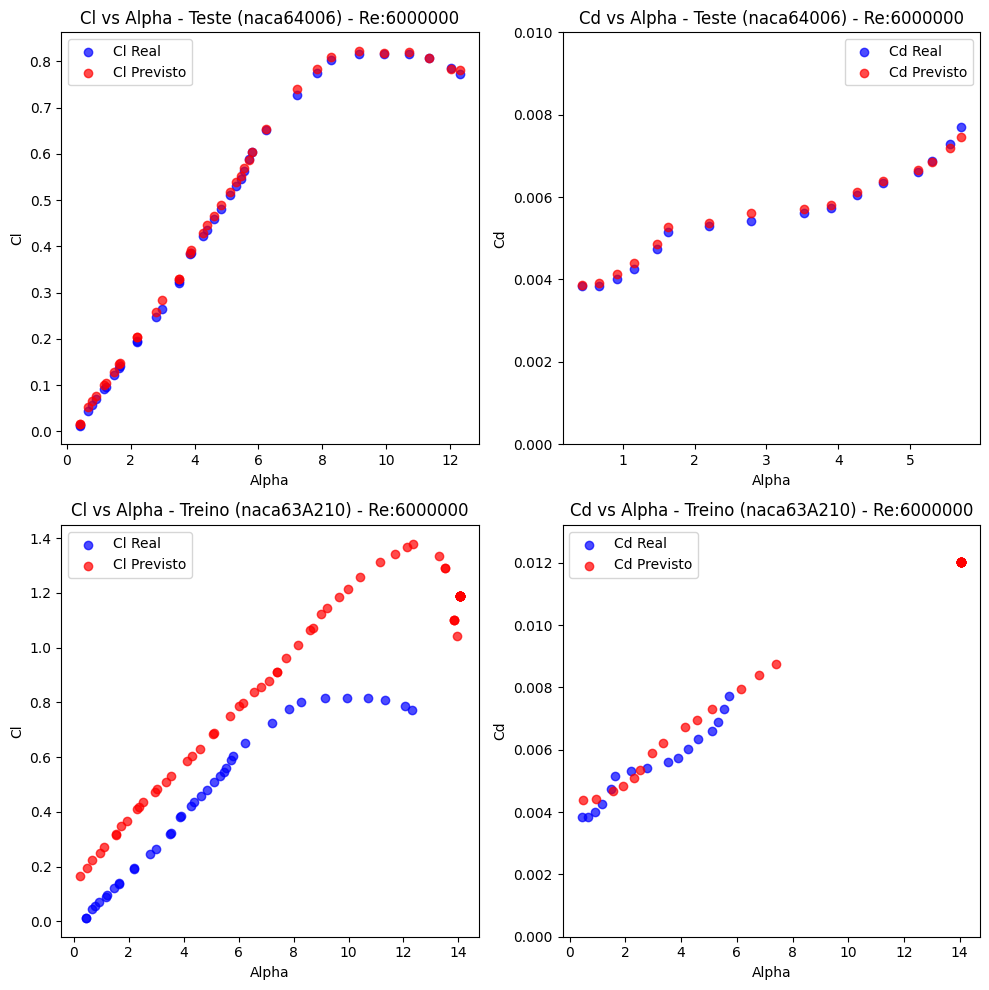

In [9]:
# Avalição visual airfoil usado para teste
np.random.seed(42)
aerofolio_escolhido_teste = np.random.choice(aerofolios_teste)
df_eval = df[df['airfoil'] == aerofolio_escolhido_teste]
Re_escolhido = np.random.choice(df_eval['Re'].unique())
df_eval = df_eval[df_eval['Re'] == Re_escolhido]
df_eval_cd = df_eval.dropna(subset=['Cd'])
features = ['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10', 'CP11', 'CP12', 'Alpha', 'Re']
X_test_cl = df_eval[features]
X_test_cd = df_eval_cd[features]
y_pred_cl = gbr_cl.predict(X_test_cl)
y_pred_cd = gbr_cd.predict(X_test_cd)

# Plots
plt.figure(figsize=(10, 10))

# Teste - Cl
plt.subplot(2, 2, 1)
plt.scatter(df_eval['Alpha'], df_eval['Cl'], color='blue', label='Cl Real', alpha=0.7)
plt.scatter(X_test_cl['Alpha'], y_pred_cl, color='red', label='Cl Previsto', alpha=0.7)
plt.xlabel('Alpha')
plt.ylabel('Cl')
plt.title(f'Cl vs Alpha - Teste ({aerofolio_escolhido_teste}) - Re:{Re_escolhido}')
plt.legend()

# Teste - Cd
plt.subplot(2, 2, 2)
plt.scatter(df_eval['Alpha'], df_eval['Cd'], color='blue', label='Cd Real', alpha=0.7)
plt.scatter(X_test_cd['Alpha'], y_pred_cd, color='red', label='Cd Previsto', alpha=0.7)
plt.ylim([0, max(0.01, y_pred_cd.max() * 1.1)])
plt.xlabel('Alpha')
plt.ylabel('Cd')
plt.title(f'Cd vs Alpha - Teste ({aerofolio_escolhido_teste}) - Re:{Re_escolhido}')
plt.legend()

# Avalição visual airfoil usado para treino
np.random.seed(42)
aerofolio_escolhido_treino = np.random.choice(aerofolios_treino)
df_eval_treino = df[df['airfoil'] == aerofolio_escolhido_treino]
Re_escolhido = np.random.choice(df_eval_treino['Re'].unique())
df_eval_treino = df_eval_treino[df_eval_treino['Re'] == Re_escolhido]
df_eval_cd = df_eval_treino.dropna(subset=['Cd'])
features = ['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10', 'CP11', 'CP12', 'Alpha', 'Re']
X_test_cl = df_eval_treino[features]
X_test_cd = df_eval_cd[features]
y_pred_cl = gbr_cl.predict(X_test_cl)
y_pred_cd = gbr_cd.predict(X_test_cd)

# Treino - Cl
plt.subplot(2, 2, 3)
plt.scatter(df_eval['Alpha'], df_eval['Cl'], color='blue', label='Cl Real', alpha=0.7)
plt.scatter(X_test_cl['Alpha'], y_pred_cl, color='red', label='Cl Previsto', alpha=0.7)
plt.xlabel('Alpha')
plt.ylabel('Cl')
plt.title(f'Cl vs Alpha - Treino ({aerofolio_escolhido_treino}) - Re:{Re_escolhido}')
plt.legend()

# Treino - Cd
plt.subplot(2, 2, 4)
plt.scatter(df_eval['Alpha'], df_eval['Cd'], color='blue', label='Cd Real', alpha=0.7)
plt.scatter(X_test_cd['Alpha'], y_pred_cd, color='red', label='Cd Previsto', alpha=0.7)
plt.ylim([0, max(0.01, y_pred_cd.max() * 1.1)])
plt.xlabel('Alpha')
plt.ylabel('Cd')
plt.title(f'Cd vs Alpha - Treino ({aerofolio_escolhido_treino}) - Re:{Re_escolhido}')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Funções auxiliares
def calcular_acuracia(y_true, y_pred, tolerancia=0.1):
    return np.mean(np.abs(y_true - y_pred) / np.abs(y_true) <= tolerancia)

def avaliar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    acc = calcular_acuracia(y_true, y_pred)
    return {'MAE': mae, 'R²': r2, 'MSE': mse, 'RMSE': rmse, 'Acurácia': acc}

# --- Configurações ---
np.random.seed(42)
n_splits = 1000  # número de folds
features = ['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CP7', 'CP8', 'CP9', 'CP10', 'CP11', 'CP12', 'Alpha', 'Re']

aerofolios_unicos = np.array(df['airfoil'].unique())
n_total = len(aerofolios_unicos)
n_teste = max(1, int(n_total * 0.1))  # pelo menos 1 aerofólio no teste

# --- Preparar folds ---
indices = np.arange(n_total)
np.random.shuffle(indices)

folds = []
for i in range(n_splits):
    inicio = (i * n_teste) % n_total
    fim = inicio + n_teste
    if fim > n_total:
        teste_idx = np.concatenate((indices[inicio:], indices[:fim - n_total]))
    else:
        teste_idx = indices[inicio:fim]
    
    treino_idx = np.setdiff1d(indices, teste_idx)
    
    aerofolios_treino = aerofolios_unicos[treino_idx]
    aerofolios_teste = aerofolios_unicos[teste_idx]
    
    folds.append((aerofolios_treino, aerofolios_teste))

# --- Treinamento e avaliação por fold ---
resultados_folds = []

for fold_idx, (aerofolios_treino, aerofolios_teste) in enumerate(folds):
    print(f"\n=== Fold {fold_idx+1} ===")
    
    # Separar os dados
    df_train_cl = df[df['airfoil'].isin(aerofolios_treino)]
    df_train_cd = df_train_cl.dropna(subset=['Cd'])
    
    df_test_cl = df[df['airfoil'].isin(aerofolios_teste)]
    df_test_cd = df_test_cl.dropna(subset=['Cd'])
    
    # Features e targets
    X_train_cl, y_train_cl = df_train_cl[features], df_train_cl['Cl'].to_numpy().ravel()
    X_test_cl, y_test_cl = df_test_cl[features], df_test_cl['Cl'].to_numpy().ravel()

    X_train_cd, y_train_cd = df_train_cd[features], df_train_cd['Cd'].to_numpy().ravel()
    X_test_cd, y_test_cd = df_test_cd[features], df_test_cd['Cd'].to_numpy().ravel()
    
    # Modelos
    modelo_cl = RandomForestRegressor(random_state=42).fit(X_train_cl, y_train_cl)
    modelo_cd = RandomForestRegressor(random_state=42).fit(X_train_cd, y_train_cd)
    
    y_pred_cl = modelo_cl.predict(X_test_cl)
    y_pred_cd = modelo_cd.predict(X_test_cd)
    
    # Avaliação
    resultado_cl = avaliar(y_test_cl, y_pred_cl)
    resultado_cd = avaliar(y_test_cd, y_pred_cd)
    
    resultados_folds.append({
        'fold': fold_idx+1,
        'aerofolios_treino': aerofolios_treino,
        'aerofolios_teste': aerofolios_teste,
        'Cl': resultado_cl,
        'Cd': resultado_cd
    })

# --- Mostrar resultados finais ---
print("\n📊 Resultados por Fold:\n")
print(f"{'Fold':<6}{'MAE Cl':<10}{'RMSE Cl':<10}{'R² Cl':<10}{'Acc Cl':<10}{'MAE Cd':<10}{'RMSE Cd':<10}{'R² Cd':<10}{'Acc Cd':<10}")

for res in resultados_folds:
    cl, cd = res['Cl'], res['Cd']
    print(f"{res['fold']:<6}{cl['MAE']:.4f}    {cl['RMSE']:.4f}    {cl['R²']:.4f}    {cl['Acurácia']:.4f}    "
          f"{cd['MAE']:.4f}    {cd['RMSE']:.4f}    {cd['R²']:.4f}    {cd['Acurácia']:.4f}")

# --- Escolher o melhor fold ---
# Critério: menor MAE para Cd
melhor_fold = min(resultados_folds, key=lambda x: x['Cd']['MAE'])

print("\n🏆 Melhor Fold:")
print(f"Fold: {melhor_fold['fold']}")
print(f"MAE Cl: {melhor_fold['Cl']['MAE']:.4f}, RMSE Cl: {melhor_fold['Cl']['RMSE']:.4f}, R² Cl: {melhor_fold['Cl']['R²']:.4f}")
print(f"MAE Cd: {melhor_fold['Cd']['MAE']:.4f}, RMSE Cd: {melhor_fold['Cd']['RMSE']:.4f}, R² Cd: {melhor_fold['Cd']['R²']:.4f}")
print(f"Acurácia Cl: {melhor_fold['Cl']['Acurácia']:.4f}, Acurácia Cd: {melhor_fold['Cd']['Acurácia']:.4f}")

print("\n📋 Aerofólios de Treino:")
print(melhor_fold['aerofolios_treino'])

print("\n📋 Aerofólios de Teste:")
print(melhor_fold['aerofolios_teste'])

print("\n✅ Processo finalizado!")


=== Fold 1 ===

=== Fold 2 ===

=== Fold 3 ===


C:\Users\joaov\AppData\Local\Temp\ipykernel_5360\1307799074.py:8: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs(y_true - y_pred) / np.abs(y_true) <= tolerancia)



=== Fold 4 ===

=== Fold 5 ===

=== Fold 6 ===

=== Fold 7 ===

=== Fold 8 ===

=== Fold 9 ===

=== Fold 10 ===

=== Fold 11 ===

=== Fold 12 ===

=== Fold 13 ===


C:\Users\joaov\AppData\Local\Temp\ipykernel_5360\1307799074.py:8: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs(y_true - y_pred) / np.abs(y_true) <= tolerancia)



=== Fold 14 ===

=== Fold 15 ===

=== Fold 16 ===

=== Fold 17 ===

=== Fold 18 ===

=== Fold 19 ===

=== Fold 20 ===

=== Fold 21 ===

=== Fold 22 ===

=== Fold 23 ===


...


=== Fold 974 ===

=== Fold 975 ===

=== Fold 976 ===

=== Fold 977 ===

=== Fold 978 ===

=== Fold 979 ===

=== Fold 980 ===

=== Fold 981 ===

=== Fold 982 ===

=== Fold 983 ===


C:\Users\joaov\AppData\Local\Temp\ipykernel_5360\1307799074.py:8: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs(y_true - y_pred) / np.abs(y_true) <= tolerancia)



=== Fold 984 ===

=== Fold 985 ===

=== Fold 986 ===

=== Fold 987 ===

=== Fold 988 ===

=== Fold 989 ===

=== Fold 990 ===

=== Fold 991 ===

=== Fold 992 ===

=== Fold 993 ===


C:\Users\joaov\AppData\Local\Temp\ipykernel_5360\1307799074.py:8: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs(y_true - y_pred) / np.abs(y_true) <= tolerancia)



=== Fold 994 ===

=== Fold 995 ===

=== Fold 996 ===

=== Fold 997 ===

=== Fold 998 ===

=== Fold 999 ===

=== Fold 1000 ===

📊 Resultados por Fold:

Fold  MAE Cl    RMSE Cl   R² Cl     Acc Cl    MAE Cd    RMSE Cd   R² Cd     Acc Cd    
1     0.1862    0.2499    0.5441    0.2231    0.0009    0.0013    0.7423    0.6693
2     1.0133    1.8051    -19.9119    0.0885    0.0020    0.0032    0.2828    0.4084
3     0.2039    0.2438    0.6437    0.1439    0.0017    0.0029    0.0440    0.5184
4     0.0867    0.1138    0.9106    0.5543    0.0008    0.0015    0.7879    0.6714
5     0.1674    0.3991    -0.2303    0.2404    0.0010    0.0018    0.7230    0.6164
6     0.1938    0.2424    0.5742    0.2724    0.0010    0.0016    0.7444    0.5771
7     0.9137    2.0538    -30.5943    0.3244    0.0010    0.0013    0.6302    0.5902
8     0.2040    0.2699    0.5003    0.3225    0.0024    0.0034    -0.4655    0.4722
9     1.5977    4.3093    -0.1073    0.0750    0.0024    0.0037    -0.3481    0.4251
10    